In [2]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from medicaid_spending.config import PARQUET_PATH

In [10]:
PCTL_CUTOFF = 0.99          # top 1% most expensive providers within a HCPCS
IMPACT_PCTL = 0.90          # among those, require excess dollars in top 10% (within HCPCS)
MIN_PROVIDERS_PER_HCPCS = 20
EPS = 1e-12

USE_LOG_Z = True
LOG_Z_CUTOFF = 2.5          # raise to be stricter, lower to be looser


In [3]:
conn = duckdb.connect()
df = conn.execute("""
    SELECT
        HCPCS_CODE,
        BILLING_PROVIDER_NPI_NUM,
        SUM(TOTAL_PAID) / SUM(TOTAL_CLAIMS) AS paid_per_claim,
        SUM(TOTAL_CLAIMS) AS total_claims
    FROM read_parquet(?)
    GROUP BY HCPCS_CODE, BILLING_PROVIDER_NPI_NUM
    HAVING SUM(TOTAL_CLAIMS) > 100
""", [str(PARQUET_PATH)]).df()

  HCPCS_CODE BILLING_PROVIDER_NPI_NUM  PAID_PER_CLAIM  TOTAL_CLAIMS  \
0      T1018               1326168840      299.428028     3133222.0   
1      A0427               1376554592     1611.369288      538903.0   
2      A0429               1376554592     1739.443399      198597.0   
3      T2016               1750504064    15363.350235       79348.0   
4      T2016               1518096411    13456.369348       76530.0   
5      99211               1427335140      543.904850      163967.0   
6      99285               1578778726      709.041984      158886.0   
7      99211               1780639971      491.005713      144914.0   
8      99284               1760480503      635.158756      129761.0   
9      99285               1184779332      813.011337      108411.0   

   HCPCS_MEDIAN_PAID_PER_CLAIM  PCT_ABOVE_MEDIAN  PCTL_WITHIN_HCPCS  \
0                    40.374100        641.633938           0.995556   
1                   164.187721        881.418878           0.996075   
2    

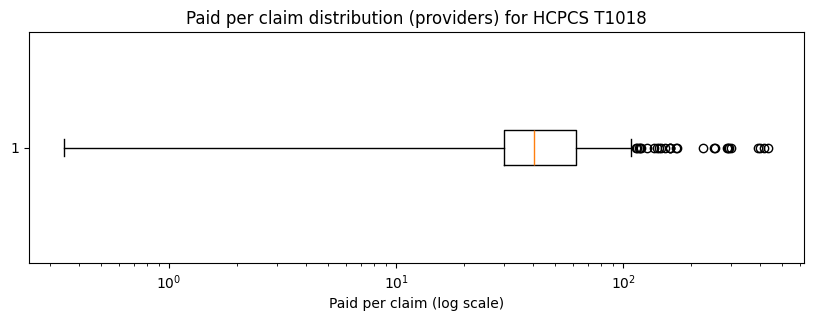

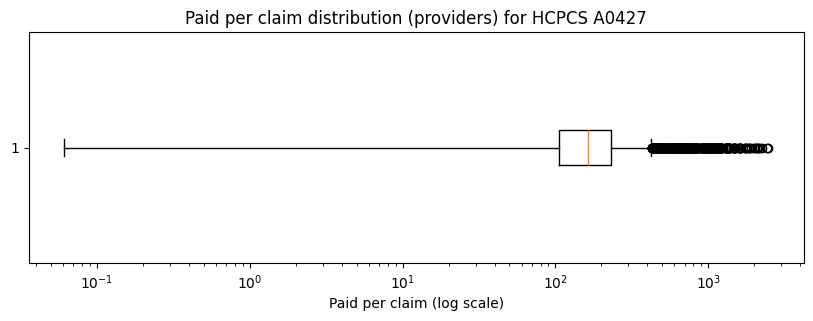

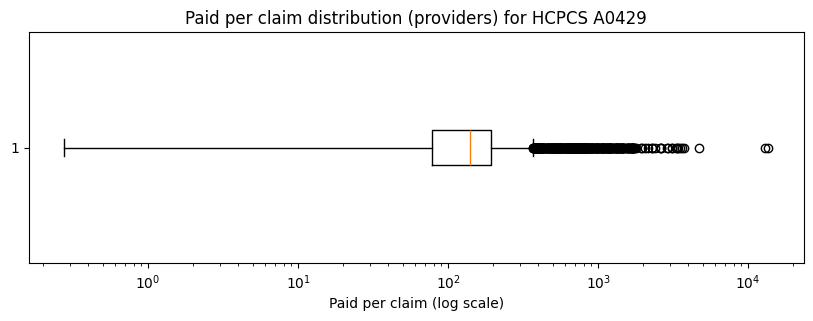

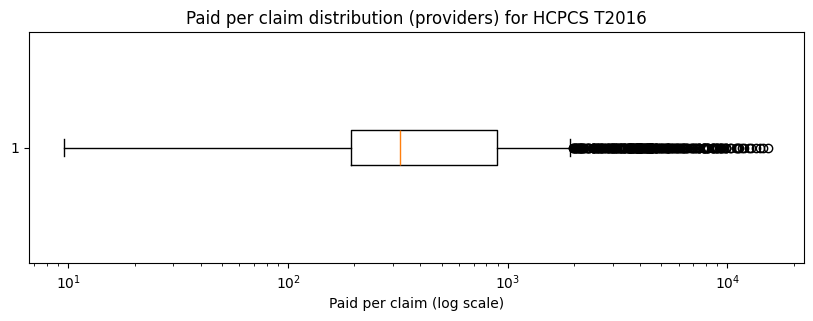

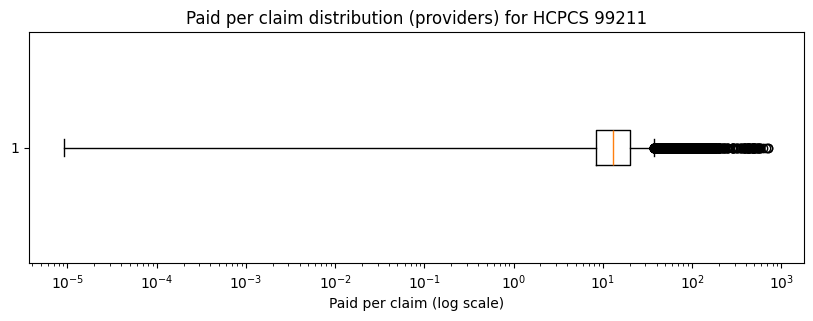

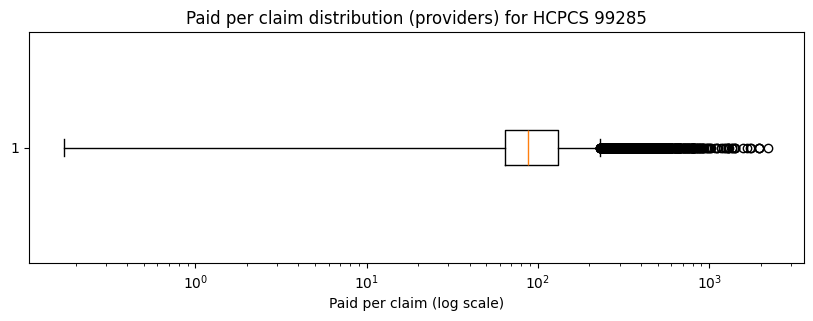

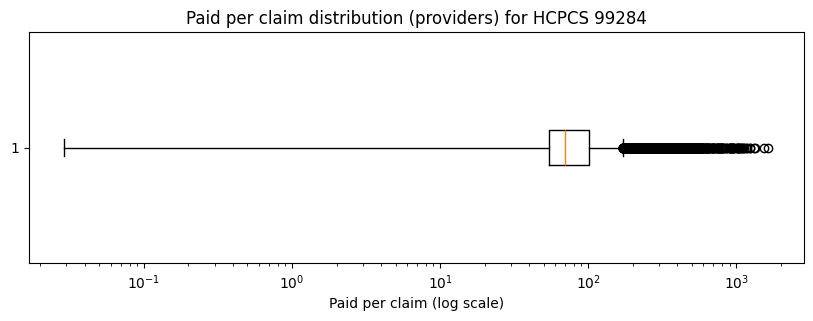

In [ ]:
CLAIMS_COL = "total_claims"
VALUE_COL = "paid_per_claim"

outliers_list = []
summary_list = []

for hcpcs, group in df.groupby("HCPCS_CODE"):
    g = group.copy()

    # Clean: log scale + ratios need positive values
    g = g[np.isfinite(g[VALUE_COL]) & (g[VALUE_COL] > 0)]
    g = g[np.isfinite(g[CLAIMS_COL]) & (g[CLAIMS_COL] > 0)]

    n_providers = len(g)
    if n_providers < MIN_PROVIDERS_PER_HCPCS:
        summary_list.append({
            "HCPCS_CODE": hcpcs,
            "N_PROVIDERS": n_providers,
            "NOTE": "Skipped: too few providers for stable outlier detection"
        })
        continue

    # Robust baseline
    median_cost = g[VALUE_COL].median()

    # How extreme is each provider within this HCPCS?
    g["PCTL_WITHIN_HCPCS"] = g[VALUE_COL].rank(pct=True)

    # Financial impact: dollars above typical * volume
    g["EXCESS_DOLLARS"] = (g[VALUE_COL] - median_cost) * g[CLAIMS_COL]
    g["EXCESS_DOLLARS"] = g["EXCESS_DOLLARS"].clip(lower=0)

    # % above median (for readability)
    g["PCT_ABOVE_MEDIAN"] = ((g[VALUE_COL] - median_cost) / median_cost) * 100.0

    # Optional: “orders of magnitude” severity in log-space
    if USE_LOG_Z:
        g["LOG_PAID"] = np.log10(g[VALUE_COL] + EPS)
        mu = g["LOG_PAID"].mean()
        sd = g["LOG_PAID"].std(ddof=0)
        g["LOG_Z"] = (g["LOG_PAID"] - mu) / sd if sd and np.isfinite(sd) and sd > 0 else np.nan
    else:
        g["LOG_Z"] = np.nan

    # Adaptive impact threshold per HCPCS (avoids guessing $ cutoffs)
    impact_cut = g["EXCESS_DOLLARS"].quantile(IMPACT_PCTL)

    # Outlier mask = extreme cost + meaningful impact (+ optional log severity)
    mask = (g["PCTL_WITHIN_HCPCS"] >= PCTL_CUTOFF) & (g["EXCESS_DOLLARS"] >= impact_cut)
    if USE_LOG_Z:
        mask = mask & (g["LOG_Z"] >= LOG_Z_CUTOFF)

    outliers = g[mask].copy()

    # A simple “investigation priority” score
    outliers["SIGNIFICANCE_SCORE"] = (
        np.log1p(outliers[CLAIMS_COL]) *
        np.log1p(outliers["EXCESS_DOLLARS"] + 1) *
        outliers["PCTL_WITHIN_HCPCS"]
    )

    # Record outliers
    for _, row in outliers.iterrows():
        outliers_list.append({
            "HCPCS_CODE": hcpcs,
            "BILLING_PROVIDER_NPI_NUM": row["BILLING_PROVIDER_NPI_NUM"],
            "PAID_PER_CLAIM": row[VALUE_COL],
            "TOTAL_CLAIMS": row[CLAIMS_COL],
            "HCPCS_MEDIAN_PAID_PER_CLAIM": median_cost,
            "PCT_ABOVE_MEDIAN": row["PCT_ABOVE_MEDIAN"],
            "PCTL_WITHIN_HCPCS": row["PCTL_WITHIN_HCPCS"],
            "EXCESS_DOLLARS": row["EXCESS_DOLLARS"],
            "IMPACT_CUTOFF": float(impact_cut),
            "LOG_Z": row["LOG_Z"],
            "SIGNIFICANCE_SCORE": row["SIGNIFICANCE_SCORE"],
        })

    summary_list.append({
        "HCPCS_CODE": hcpcs,
        "N_PROVIDERS": n_providers,
        "MEDIAN_PAID_PER_CLAIM": median_cost,
        "IMPACT_CUTOFF_EXCESS_DOLLARS_PCTL": IMPACT_PCTL,
        "IMPACT_CUTOFF_EXCESS_DOLLARS": float(impact_cut),
        "N_OUTLIERS_FLAGGED": len(outliers),
        "TOTAL_EXCESS_DOLLARS_FLAGGED": float(outliers["EXCESS_DOLLARS"].sum()) if len(outliers) else 0.0
    })

outliers_df = pd.DataFrame(outliers_list)
summary_table = pd.DataFrame(summary_list)

if outliers_df.empty:
    print("No outliers found with current thresholds.")
    print("Try one or more of:")
    print(" - PCTL_CUTOFF = 0.98 (top 2%)")
    print(" - IMPACT_PCTL = 0.80 (top 20% by excess dollars)")
    print(" - LOG_Z_CUTOFF = 2.0 or set USE_LOG_Z=False")
else:
    final_table = (
        outliers_df
        .sort_values(["SIGNIFICANCE_SCORE", "EXCESS_DOLLARS"], ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    print(final_table)

    # Plot the HCPCS codes involved
    top_hcpcs = final_table["HCPCS_CODE"].unique()
    for hcpcs in top_hcpcs:
        g = df[df["HCPCS_CODE"] == hcpcs].copy()
        g = g[np.isfinite(g[VALUE_COL]) & (g[VALUE_COL] > 0)]

        plt.figure(figsize=(10, 3))
        plt.boxplot(g[VALUE_COL], vert=False, showfliers=True)
        plt.xscale("log")
        plt.title(f"Paid per claim distribution (providers) for HCPCS {hcpcs}")
        plt.xlabel("Paid per claim (log scale)")
        plt.show()